In [1]:
from src.dg import DataGenerator
from src.run_experiments import run
from src.utils import plot

import torch
import numpy as np

Error importing in API mode: ImportError("dlopen(/Users/huimin/Documents/UNIGE PhD/research/nonparametric/.venv/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <1984CB9B-890E-3855-A246-270AC6AC4C62> /Users/huimin/Documents/UNIGE PhD/research/nonparametric/.venv/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
torch.manual_seed(42)

In [3]:
# global parameters
N = 2000

# new samples
n_samples = 2000

# number of inits for the EM - sklearn and our method
n_inits=20

crit = 'bic'
ct = 'diag'

In [4]:
pc = 0.5
pam_range = [0.05, 0.1, 0.2, 0.3, 0.4]

In [5]:
pc_range = [0.99, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.1]

## Case 1: Gaussian mixture with $k=5$

best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 4
best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 5


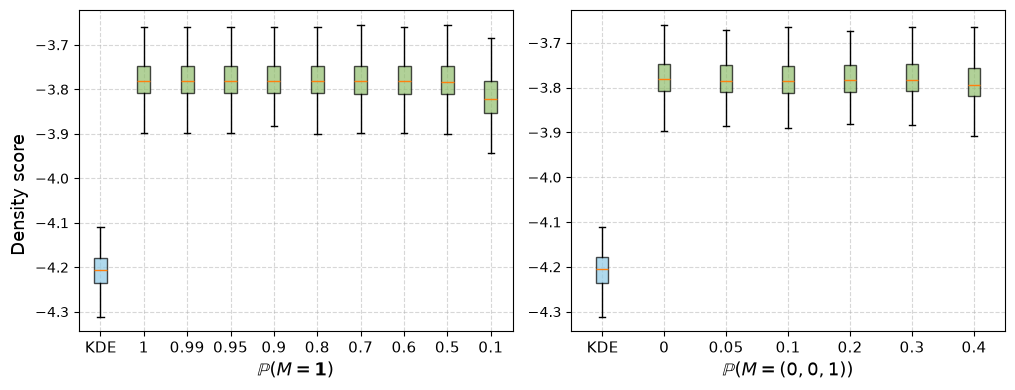

In [6]:
d = 3

k_range = range(2, 9)

dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 5

mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()

dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, _ = dg.generate(N, d)

# generate test data
X_test = [dg.generate(N, d)[0] for _ in range(100)]

dss, edss = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pc_range,
    pc=None, 
    var_complete=True
    )

dss1, edss1 = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pam_range,
    pc=pc, 
    var_complete=False
    )

plot(dss, dss1, pc_range, pam_range, legend=False, is_ds=True)

In [7]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

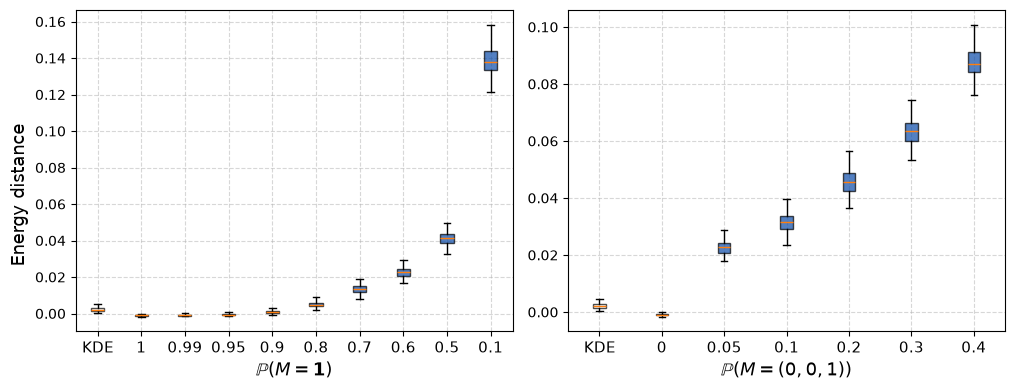

In [8]:
edss1 = np.array(edss1)
edss1_ = np.delete(edss1, 1, axis=0).T

edss = np.array(edss)
edss_ = np.delete(edss, 1, axis=0).T

plot(edss_, edss1_, pc_range, pam_range, legend=False, is_ds=False)

### Case 2: Gaussian mixture with $k=20$

best k = 9
best k = 9
best k = 13
best k = 11
best k = 8
best k = 13
best k = 9
best k = 12
best k = 8
best k = 12
best k = 8
best k = 9
best k = 9
best k = 8
best k = 8


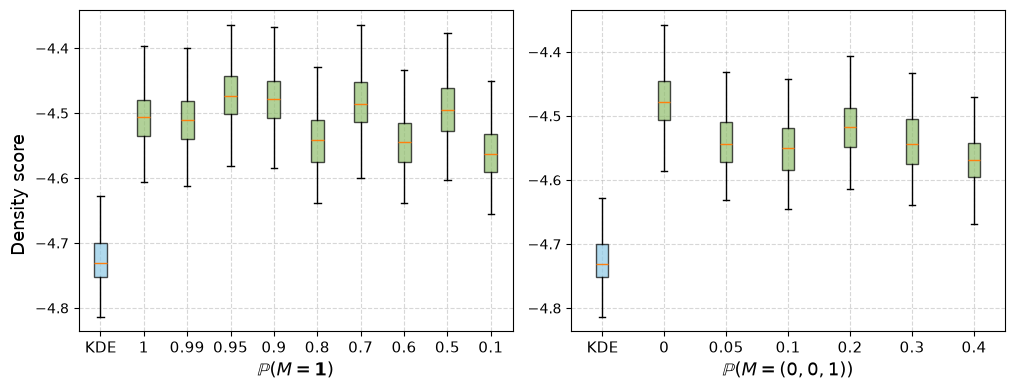

In [9]:
d = 3

k_range = range(8, 30)

dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 20

mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()

dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, _ = dg.generate(N, d)

# generate test data
X_test = [dg.generate(N, d)[0] for _ in range(100)]

dss, edss = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pc_range,
    pc=None, 
    var_complete=True
    )

dss1, edss1 = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pam_range,
    pc=pc, 
    var_complete=False
    )

plot(dss, dss1, pc_range, pam_range, legend=False, is_ds=True)

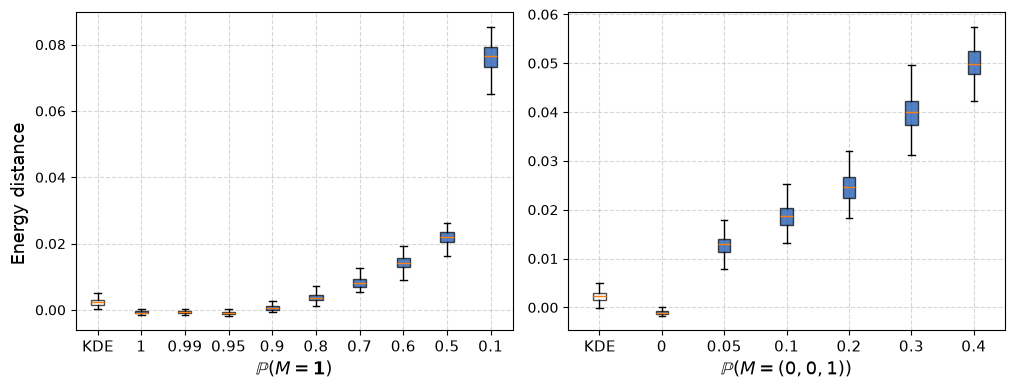

In [10]:
edss1 = np.array(edss1)
edss1_ = np.delete(edss1, 1, axis=0).T

edss = np.array(edss)
edss_ = np.delete(edss, 1, axis=0).T

plot(edss_, edss1_, pc_range, pam_range, legend=False, is_ds=False)

### Case 3: Logistic distribution

best k = 94
best k = 92
best k = 93
best k = 88
best k = 88
best k = 88
best k = 90
best k = 88
best k = 88
best k = 88
best k = 88
best k = 88
best k = 89
best k = 89
best k = 90


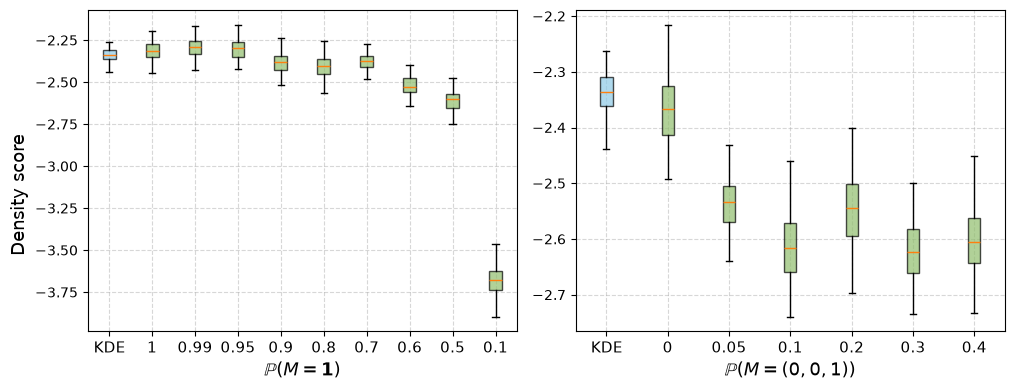

In [11]:
d = 3
k_range = range(88,95)

# param_vals
dist = 'Logistic' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, _ = dg.generate(N, d)

#generate test data
X_test = [dg.generate(N, d)[0] for _ in range(100)]

dss, edss = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pc_range,
    pc=None, 
    var_complete=True
    )

dss1, edss1 = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pam_range,
    pc=pc, 
    var_complete=False
    )

plot(dss, dss1, pc_range, pam_range, legend=False, is_ds=True)

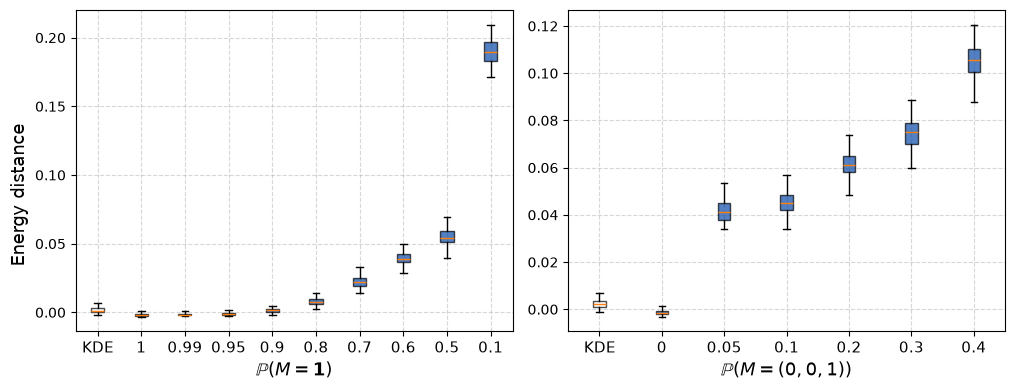

In [12]:
edss1 = np.array(edss1)
edss1_ = np.delete(edss1, 1, axis=0).T

edss = np.array(edss)
edss_ = np.delete(edss, 1, axis=0).T

plot(edss_, edss1_, pc_range, pam_range, legend=False, is_ds=False)

### Case 4: Normal distribution

best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 5
best k = 3
best k = 5
best k = 5
best k = 5
best k = 4
best k = 4
best k = 4


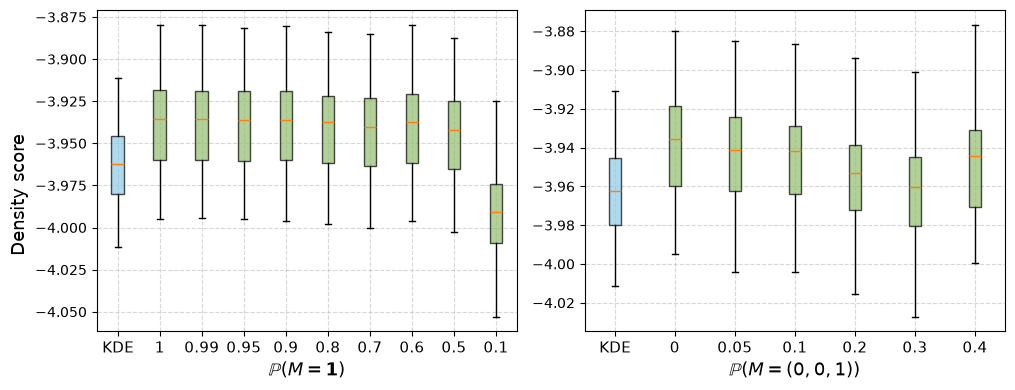

In [13]:
d = 3
k_range = range(2, 9)

# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, _ = dg.generate(N, d)

#generate test data
X_test = [dg.generate(N, d)[0] for _ in range(100)]

dss, edss = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pc_range,
    pc=None, 
    var_complete=True
    )

dss1, edss1 = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pam_range,
    pc=pc, 
    var_complete=False
    )

plot(dss, dss1, pc_range, pam_range, legend=False, is_ds=True)

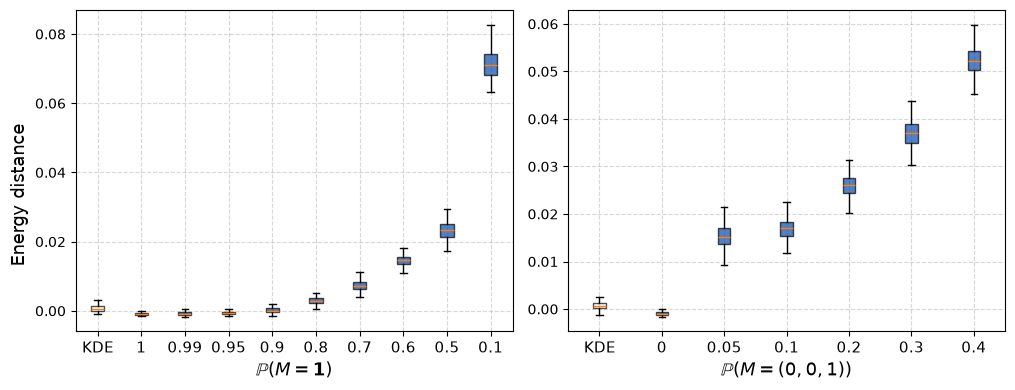

In [14]:
edss1 = np.array(edss1)
edss1_ = np.delete(edss1, 1, axis=0).T

edss = np.array(edss)
edss_ = np.delete(edss, 1, axis=0).T

plot(edss_, edss1_, pc_range, pam_range, legend=False, is_ds=False)

## Case 5: Logistic $d=20$

best k = 94
best k = 88
best k = 88
best k = 88
best k = 88
best k = 88
best k = 90
best k = 88
best k = 88
best k = 88
best k = 88
best k = 88
best k = 90
best k = 88
best k = 88


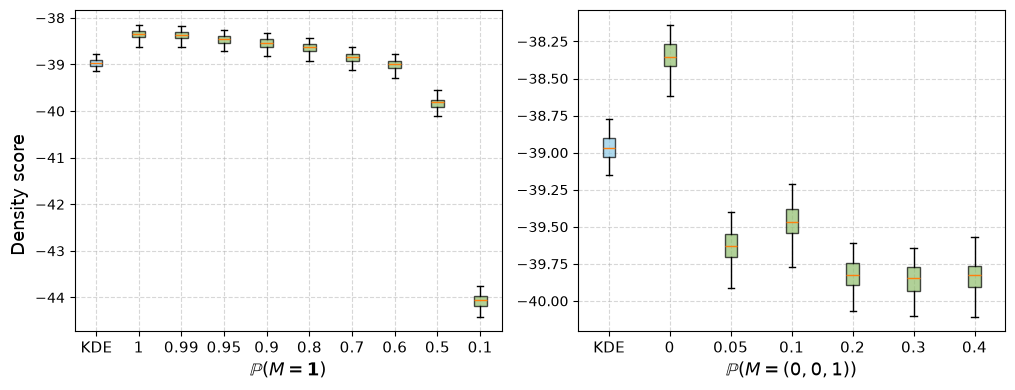

In [15]:
d = 20
k_range = range(88,95)

# param_vals
dist = 'Logistic' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, _ = dg.generate(N, d)

#generate test data
X_test = [dg.generate(N, d)[0] for _ in range(100)]

dss, edss = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pc_range,
    pc=None, 
    var_complete=True
    )

dss1, edss1 = run(
    X=X, 
    X_test=X_test,
    n_samples=n_samples,
    k_range=k_range,
    crit=crit,
    n_inits=n_inits,
    ct=ct,
    p_range=pam_range,
    pc=pc, 
    var_complete=False
    )

plot(dss, dss1, pc_range, pam_range, legend=False, is_ds=True)

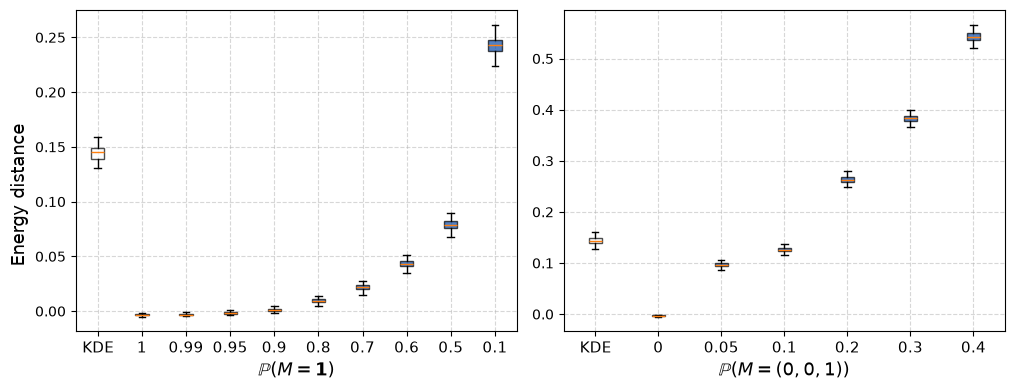

In [16]:
edss1 = np.array(edss1)
edss1_ = np.delete(edss1, 1, axis=0).T

edss = np.array(edss)
edss_ = np.delete(edss, 1, axis=0).T

plot(edss_, edss1_, pc_range, pam_range, legend=False, is_ds=False)